[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/12_montecarlo/notebooks/aplicaciones/08_epidemias_sir.ipynb)

# Aplicación 8: Epidemias Estocásticas (Modelo SIR)

## El modelo que todo el mundo vio en 2020

Durante COVID-19, los gobiernos tomaron decisiones basadas en modelos epidemiológicos.
La mayoría de los que viste en los medios era el modelo **SIR** (o sus extensiones).

Pero el modelo SIR *determinístico* que estudiaron en cálculo tiene un problema serio:
**asume que el futuro está completamente determinado por el estado actual**.

La realidad es diferente. Una epidemia puede extinguirse espontáneamente incluso con $R_0 > 1$.
La velocidad de propagación varía aleatoriamente. La fecha del pico es incierta.

El modelo SIR *estocástico* captura toda esta incertidumbre — y Monte Carlo lo simula.

## Lo que aprenderás

- Por qué los modelos deterministas dan una imagen incompleta
- Cómo la aleatoriedad genera distribuciones de resultados (no una sola trayectoria)
- Qué significa $R_0$ probabilísticamente: umbral de epidemia, no certeza
- Cómo estimar el umbral de inmunidad de rebaño via simulación

In [ ]:
# Descomenta si estás en Colab
# !pip install numpy matplotlib scipy --quiet

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.size"] = 11
COLORS = {"blue":"#2E86AB","red":"#E94F37","green":"#27AE60","orange":"#F39C12","purple":"#8E44AD"}

rng = np.random.default_rng(42)
print("Imports listos ✓")

Imports listos ✓


---
## Sección 1: El Modelo SIR Determinístico

### Las ecuaciones

El modelo SIR divide la población en tres compartimentos:
- **S** (Susceptibles): personas que pueden infectarse
- **I** (Infectados): personas actualmente contagiosas
- **R** (Recuperados): personas ya inmunes

Las ecuaciones diferenciales son:

$$\frac{dS}{dt} = -\beta \frac{SI}{N}, \quad
\frac{dI}{dt} = \beta \frac{SI}{N} - \gamma I, \quad
\frac{dR}{dt} = \gamma I$$

con $N = S + I + R$ (constante).

El parámetro clave es $R_0 = \beta / \gamma$: el número reproductivo básico.
- $R_0 < 1$: la epidemia se extingue
- $R_0 > 1$: la epidemia crece

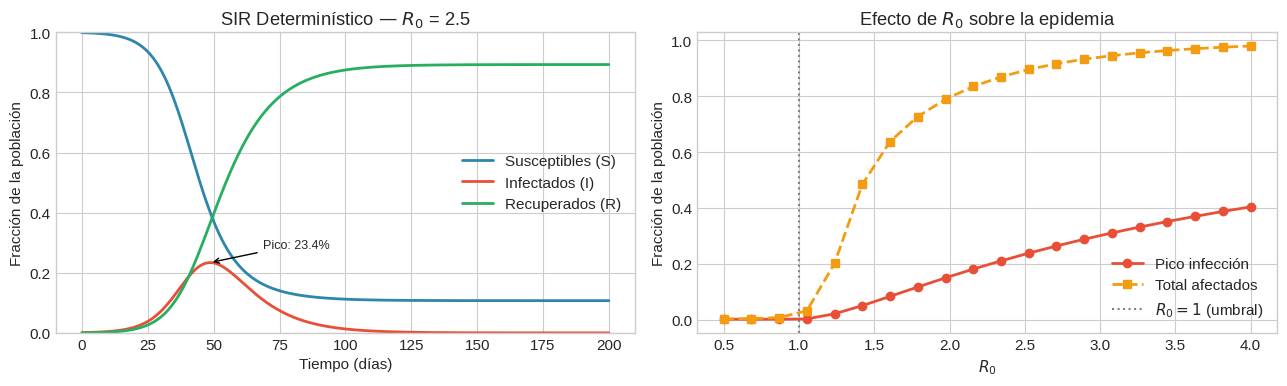

R0 = 2.5: pico de infección = 23.4%, total afectados = 89.3%


In [2]:
def sir_ode(y, t, beta, gamma):
    S, I, R = y
    N = S + I + R
    dS = -beta * S * I / N
    dI =  beta * S * I / N - gamma * I
    dR =  gamma * I
    return [dS, dI, dR]

def run_sir_deterministic(N, I0, beta, gamma, t_max=200):
    """Resuelve el sistema ODE del modelo SIR."""
    y0 = [N - I0, I0, 0]
    t = np.linspace(0, t_max, t_max * 2)
    sol = odeint(sir_ode, y0, t, args=(beta, gamma))
    return t, sol[:, 0], sol[:, 1], sol[:, 2]

# Parámetros base (tipo COVID-19 temprano)
N = 10_000
I0 = 10
beta  = 0.25
gamma = 0.1
R0 = beta / gamma

t, S, I, R = run_sir_deterministic(N, I0, beta, gamma)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(t, S/N, color=COLORS["blue"],  lw=2, label="Susceptibles (S)")
ax1.plot(t, I/N, color=COLORS["red"],   lw=2, label="Infectados (I)")
ax1.plot(t, R/N, color=COLORS["green"], lw=2, label="Recuperados (R)")
ax1.set_xlabel("Tiempo (días)"); ax1.set_ylabel("Fracción de la población")
ax1.set_title(f"SIR Determinístico — $R_0$ = {R0:.1f}")
ax1.legend()
ax1.set_ylim(0, 1)

# Peak infected and total affected
peak_I = I.max() / N
final_R = R[-1] / N
ax1.annotate(f"Pico: {peak_I:.1%}", xy=(t[I.argmax()], peak_I),
             xytext=(t[I.argmax()]+20, peak_I+0.05),
             arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)

# R0 sensitivity
R0_range = np.linspace(0.5, 4.0, 20)
peaks = []
finals = []
for r0 in R0_range:
    beta_r = r0 * gamma
    _, _, I_r, R_r = run_sir_deterministic(N, I0, beta_r, gamma)
    peaks.append(I_r.max() / N)
    finals.append(R_r[-1] / N)

ax2.plot(R0_range, peaks, "o-", color=COLORS["red"], lw=2, label="Pico infección")
ax2.plot(R0_range, finals, "s--", color=COLORS["orange"], lw=2, label="Total afectados")
ax2.axvline(1.0, color="gray", ls=":", lw=1.5, label="$R_0 = 1$ (umbral)")
ax2.set_xlabel("$R_0$"); ax2.set_ylabel("Fracción de la población")
ax2.set_title("Efecto de $R_0$ sobre la epidemia")
ax2.legend()
plt.tight_layout()
plt.show()
print(f"R0 = {R0:.1f}: pico de infección = {peak_I:.1%}, total afectados = {final_R:.1%}")

### El problema con el modelo determinístico

El modelo ODE da una respuesta única para cada conjunto de parámetros. Pero en la realidad:
- ¿Ocurre realmente una epidemia si I₀ = 1 y R₀ = 1.5?
- ¿Con cuánta probabilidad?
- ¿Cuándo llega el pico?
- ¿Qué fracción de la población se infecta?

El modelo determinístico no puede responder estas preguntas — da un número, no una distribución.
El modelo estocástico sí.

---
## Sección 2: El Modelo SIR Estocástico

### Eventos discretos aleatorios

En el modelo estocástico, cada "evento" (infección, recuperación) ocurre con una probabilidad
por unidad de tiempo. En un intervalo $\Delta t$ pequeño:

$$P(\text{una infección}) = \beta \frac{S \cdot I}{N} \cdot \Delta t$$
$$P(\text{una recuperación}) = \gamma \cdot I \cdot \Delta t$$

Con poblaciones pequeñas, los números son discretos — no puedes tener 3.7 infectados.
Y la aleatoriedad del proceso hace que el resultado sea diferente en cada simulación.

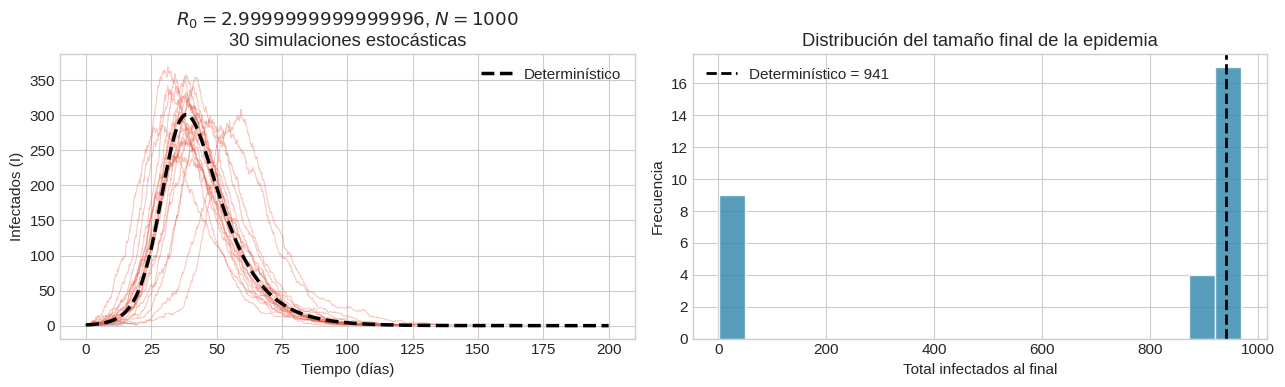

Simulaciones con epidemia pequeña (<5% de N): 9/30 (30%)
Pico promedio:          219 personas
Total afectados (med):  932 personas
Determinístico predice: pico=301, total=941


In [3]:
def sir_stochastic(N, I0, beta, gamma, t_max=300, dt=0.1):
    """
    Simulación estocástica del modelo SIR (tiempo discreto).
    Returns: arrays de tiempo, S, I, R.
    """
    S, I, R = N - I0, I0, 0
    t = 0
    ts, Ss, Is, Rs = [t], [S], [I], [R]
    
    while t < t_max and I > 0:
        # Expected number of events
        n_infections  = beta * S * I / N * dt
        n_recoveries  = gamma * I * dt
        # Actual number (Poisson sampling)
        new_infections = rng.poisson(n_infections)
        new_recoveries = rng.poisson(n_recoveries)
        # Cap to avoid negative compartments
        new_infections = min(new_infections, S)
        new_recoveries = min(new_recoveries, I)
        # Update
        S -= new_infections
        I += new_infections - new_recoveries
        R += new_recoveries
        t += dt
        ts.append(t); Ss.append(S); Is.append(I); Rs.append(R)
    
    return np.array(ts), np.array(Ss), np.array(Is), np.array(Rs)

# Run multiple simulations with same parameters → different outcomes
N = 1000
I0 = 1
beta  = 0.3
gamma = 0.1
R0 = beta / gamma

n_runs = 30  # <-- CHANGE THIS
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

all_peaks = []
all_finals = []
extinct = 0

for run in range(n_runs):
    t_s, S_s, I_s, R_s = sir_stochastic(N, I0, beta, gamma)
    final_R = R_s[-1]
    peak_I = I_s.max()
    alpha = 0.3 if n_runs > 15 else 0.6
    color = COLORS["red"] if final_R > N * 0.1 else COLORS["blue"]
    axes[0].plot(t_s, I_s, lw=0.8, color=color, alpha=alpha)
    all_peaks.append(peak_I)
    all_finals.append(final_R)
    if final_R < N * 0.05:
        extinct += 1

# Add deterministic for comparison
t_det, _, I_det, R_det = run_sir_deterministic(N, I0, beta, gamma)
axes[0].plot(t_det, I_det, "k--", lw=2.5, label="Determinístico", zorder=10)
axes[0].set_xlabel("Tiempo (días)")
axes[0].set_ylabel("Infectados (I)")
axes[0].set_title(f"$R_0 = {R0}$, $N = {N}$\n{n_runs} simulaciones estocásticas")
axes[0].legend()

axes[1].hist(all_finals, bins=20, color=COLORS["blue"], edgecolor="white", alpha=0.8)
axes[1].axvline(R_det[-1], color="black", lw=2, ls="--", label=f"Determinístico = {R_det[-1]:.0f}")
axes[1].set_xlabel("Total infectados al final")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title(f"Distribución del tamaño final de la epidemia")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Simulaciones con epidemia pequeña (<5% de N): {extinct}/{n_runs} ({extinct/n_runs:.0%})")
print(f"Pico promedio:          {np.mean(all_peaks):.0f} personas")
print(f"Total afectados (med):  {np.median(all_finals):.0f} personas")
print(f"Determinístico predice: pico={I_det.max():.0f}, total={R_det[-1]:.0f}")

### Conclusión: modelo SIR estocástico

Con los mismos parámetros, el modelo determinístico produce una sola trayectoria, pero el modelo estocástico genera una distribución de resultados.

Al usar $I_0 = 1$ y varias corridas, se observa claramente que algunas simulaciones se extinguen temprano y otras generan una epidemia grande. Esto muestra que $R_0 > 1$ no significa certeza de epidemia, sino mayor probabilidad de que ocurra.

### La distribución bimodal

Con R₀ > 1 y población pequeña, la distribución del tamaño final de la epidemia suele ser **bimodal**:
- Una moda cerca de cero: la epidemia se extingue antes de crecer ("early extinction")
- Una moda alrededor del valor determinístico: epidemia completa

El modelo determinístico solo ve el segundo modo. El primero — epidemias que mueren solas — es invisible.

Esto tiene implicaciones reales: si introduces un caso importado a una ciudad, hay una probabilidad
genuina de que simplemente se extinga sin generar brote.

---
## Sección 3: $R_0$ y la Probabilidad de Epidemia

### La teoría de ramificación

Cuando la epidemia empieza con pocos infectados (I₀ pequeño), el proceso se puede aproximar
con una **cadena de Galton-Watson**: cada infectado "engendra" un número aleatorio de contagios.

La teoría de ramificación predice que para $R_0 > 1$:

$$P(\text{extinción}) \approx \left(\frac{1}{R_0}\right)^{I_0}$$

Para $I_0 = 1$: $P(\text{extinción}) \approx 1/R_0$.

Esto significa que incluso con $R_0 = 2$ (doble de contagioso que necesario), la epidemia
**se extingue con ~50% de probabilidad** si empieza con un solo caso.

Calculando P(extinción) para 20 valores de R0...
(I0 = 5, N = 5,000)


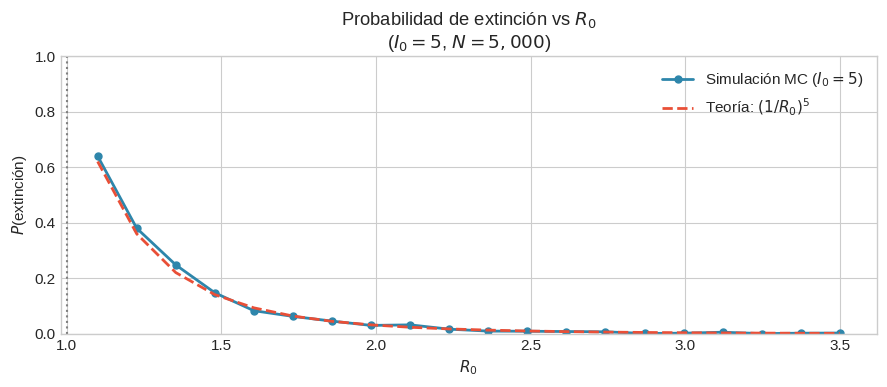

In [4]:
# P(extinción) vs R0: teoría vs simulación
R0_values = np.linspace(1.1, 3.5, 20)
n_sims = 2_000
I0_test = 5
N_test = 5_000
gamma_test = 0.1

p_extinct_sim = []
p_extinct_theory = []

print(f"Calculando P(extinción) para {len(R0_values)} valores de R0...")
print(f"(I0 = {I0_test}, N = {N_test:,})")
for R0_val in R0_values:
    beta_val = R0_val * gamma_test
    extinct_count = 0
    for _ in range(n_sims):
        _, _, _, R_arr = sir_stochastic(N_test, I0_test, beta_val, gamma_test, t_max=500)
        if R_arr[-1] < N_test * 0.05:   # < 5% → extinguished
            extinct_count += 1
    p_extinct_sim.append(extinct_count / n_sims)
    p_extinct_theory.append((1/R0_val)**I0_test)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(R0_values, p_extinct_sim, "o-", color=COLORS["blue"], lw=2, ms=5,
        label=f"Simulación MC ($I_0 = {I0_test}$)")
ax.plot(R0_values, p_extinct_theory, "--", color=COLORS["red"], lw=2,
        label=f"Teoría: $(1/R_0)^{{{I0_test}}}$")
ax.axvline(1.0, color="gray", ls=":", lw=1.5)
ax.set_xlabel("$R_0$")
ax.set_ylabel("$P$(extinción)")
ax.set_title(f"Probabilidad de extinción vs $R_0$\n($I_0 = {I0_test}$, $N = {N_test:,}$)")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Conclusión: probabilidad de extinción

Al aumentar $I_0$, la probabilidad de extinción baja de forma importante.

Con $I_0 = 5$, la curva simulada sigue razonablemente bien la aproximación teórica
$
P(\text{extinción}) \approx \left(\frac{1}{R_0}\right)^{I_0},
$
aunque sigue habiendo diferencias por tamaño finito de población y por el criterio práctico usado para definir “extinción”.

---
## Sección 4: Inmunidad de Rebaño

### ¿Qué fracción de la población necesita ser inmune para detener la epidemia?

La teoría del modelo determinístico predice que la epidemia se detiene cuando:

$$S < \frac{N}{R_0} \quad \Longleftrightarrow \quad \text{fracción inmune} > 1 - \frac{1}{R_0}$$

Para $R_0 = 2.5$: umbral de rebaño = 60%.
Para $R_0 = 4$: umbral de rebaño = 75%.

Pero el modelo estocástico revela matices: incluso por encima del umbral de rebaño determinístico,
puede haber epidemias pequeñas. Y justo debajo, la epidemia puede extinguirse.

R0 = 4, umbral teórico = 75.0%
Simulando para diferentes niveles de inmunidad...


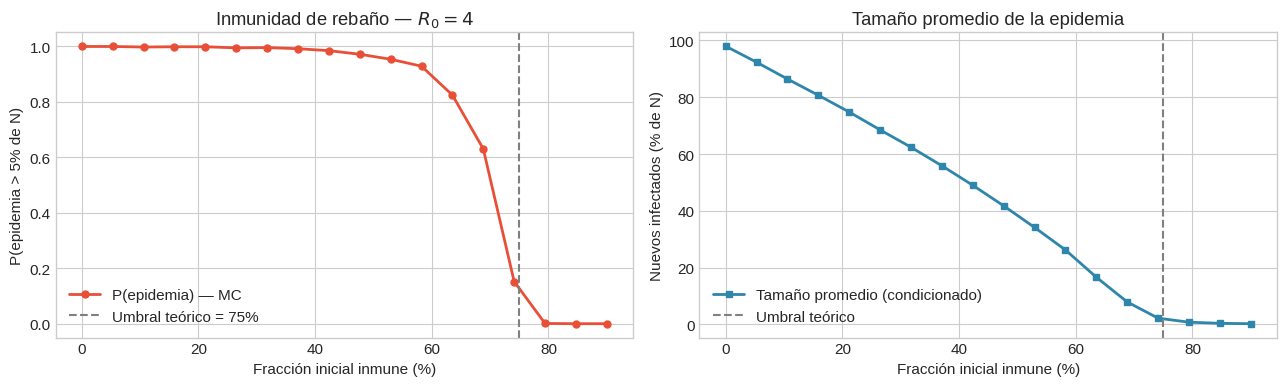


Con 75% inmunes, P(epidemia) = 15.20%


In [5]:
# Herd immunity threshold: simulation
# Fix R0, vary initial immune fraction, measure P(epidemic) and final size

R0_herd = 4
gamma_herd = 0.1
beta_herd = R0_herd * gamma_herd
N_herd = 3_000
I0_herd = 5
n_sims_herd = 1_000

immune_fracs = np.linspace(0, 0.90, 18)   # fraction of initial immune (= initial R)
theoretical_threshold = 1 - 1/R0_herd

p_epidemic = []
mean_final_size = []

print(f"R0 = {R0_herd}, umbral teórico = {theoretical_threshold:.1%}")
print("Simulando para diferentes niveles de inmunidad...")

for frac in immune_fracs:
    R_init = int(frac * N_herd)
    S_init = N_herd - R_init - I0_herd
    if S_init <= 0:
        p_epidemic.append(0.0)
        mean_final_size.append(0.0)
        continue
    
    epidemics = 0
    final_sizes = []
    for _ in range(n_sims_herd):
        # Simulate with pre-immune population
        S, I, R_comp = S_init, I0_herd, R_init
        t_step, dt_step = 0, 0.1
        while t_step < 400 and I > 0:
            new_inf = min(rng.poisson(beta_herd * S * I / N_herd * dt_step), S)
            new_rec = min(rng.poisson(gamma_herd * I * dt_step), I)
            S -= new_inf; I += new_inf - new_rec; R_comp += new_rec
            t_step += dt_step
        new_immune = R_comp - R_init
        final_sizes.append(new_immune)
        if new_immune > N_herd * 0.05:
            epidemics += 1
    
    p_epidemic.append(epidemics / n_sims_herd)
    mean_final_size.append(np.mean(final_sizes))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(immune_fracs * 100, p_epidemic, "o-", color=COLORS["red"], lw=2, ms=5,
         label="P(epidemia) — MC")
ax1.axvline(theoretical_threshold * 100, color="gray", ls="--", lw=1.5,
            label=f"Umbral teórico = {theoretical_threshold:.0%}")
ax1.set_xlabel("Fracción inicial inmune (%)")
ax1.set_ylabel("P(epidemia > 5% de N)")
ax1.set_title(f"Inmunidad de rebaño — $R_0 = {R0_herd}$")
ax1.legend(); ax1.set_ylim(-0.05, 1.05)

ax2.plot(immune_fracs * 100, [s/N_herd*100 for s in mean_final_size], "s-",
         color=COLORS["blue"], lw=2, ms=5, label="Tamaño promedio (condicionado)")
ax2.axvline(theoretical_threshold * 100, color="gray", ls="--", lw=1.5,
            label=f"Umbral teórico")
ax2.set_xlabel("Fracción inicial inmune (%)")
ax2.set_ylabel("Nuevos infectados (% de N)")
ax2.set_title("Tamaño promedio de la epidemia")
ax2.legend()
plt.tight_layout()
plt.show()

print(f"\nCon {theoretical_threshold:.0%} inmunes, P(epidemia) = "
      f"{p_epidemic[np.argmin(np.abs(immune_fracs - theoretical_threshold))]:.2%}")

### Conclusión: inmunidad de rebaño

Para $R_0 = 4$, el umbral teórico de inmunidad de rebaño es

$
1 - \frac{1}{R_0} = 1 - \frac{1}{4} = 0.75.
$

La simulación confirma que al acercarnos a 75% de inmunidad inicial, la probabilidad de epidemia grande cae con fuerza. Sin embargo, el modelo estocástico muestra que el umbral no es una frontera perfectamente rígida: justo debajo todavía puede haber extinción y justo arriba aún pueden ocurrir brotes pequeños.

### 🔧 Ejercicios

1. **Cuarentena**: implementa una intervención que reduce $\beta$ a la mitad
   a partir del día 30. ¿Cuánto reduce el tamaño final de la epidemia?

2. **Superspreaders**: modifica el modelo para que un 10% de los infectados
   tenga tasa de transmisión $5\beta$ (y el resto $0.5\beta$).
   ¿Cómo cambia la distribución del tamaño de la epidemia?

3. **Detección tardía**: empieza con $I_0 = 50$ pero $R_0 = 1.2$.
   ¿Cuántas simulaciones producen epidemias? ¿Cuánto tiempo pasa antes de
   que el determinístico y el estocástico divergen visiblemente?

Sin superspreaders -> media tamaño final: 41.58%, std: 39.79%
Con superspreaders -> media tamaño final: 35.81%, std: 38.19%

Sin superspreaders -> P(extinción <5%): 48.00%
Con superspreaders -> P(extinción <5%): 53.40%


/tmp/ipykernel_17650/1860820006.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([peak_base * 100, peak_super * 100],


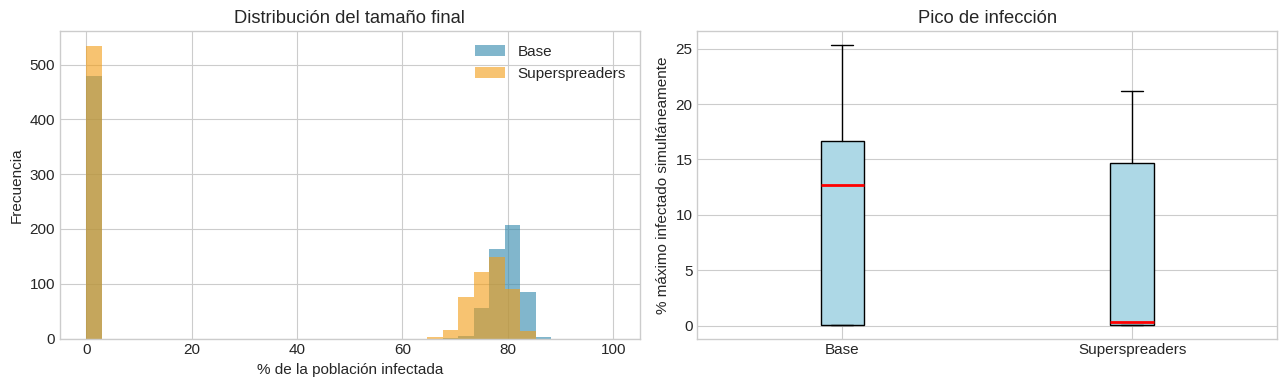

R0 = 1.20
Simulaciones con epidemia (>5% de N): 400/400 = 100.00%
Tamaño final promedio (estocástico): 37.15%
Tamaño final determinístico:        38.09%
Con este criterio (2 puntos porcentuales), no hubo divergencia visible clara entre la media estocástica y el determinístico.


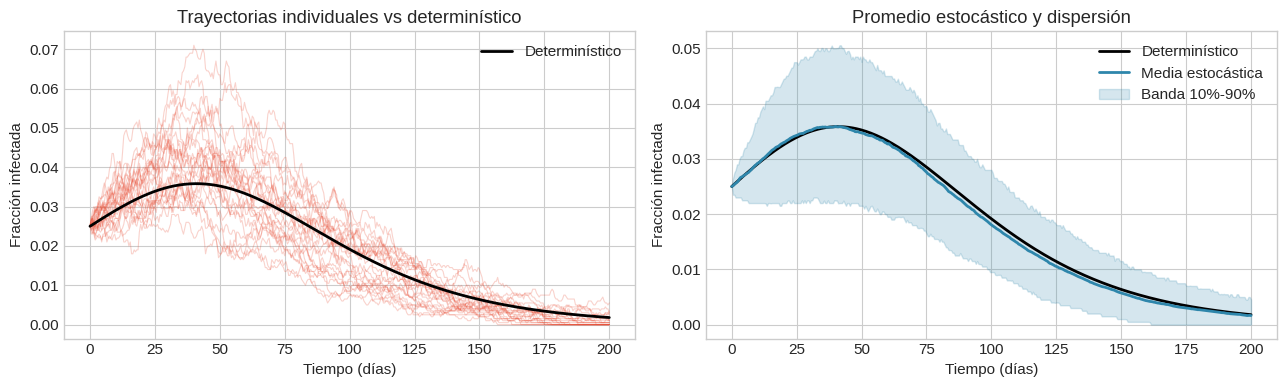

Tamaño final promedio sin cuarentena: 89.40%
Tamaño final promedio con cuarentena: 59.71%
Reducción relativa del tamaño final: 33.21%

Pico promedio sin cuarentena: 24.14%
Pico promedio con cuarentena: 15.16%
Reducción relativa del pico: 37.21%


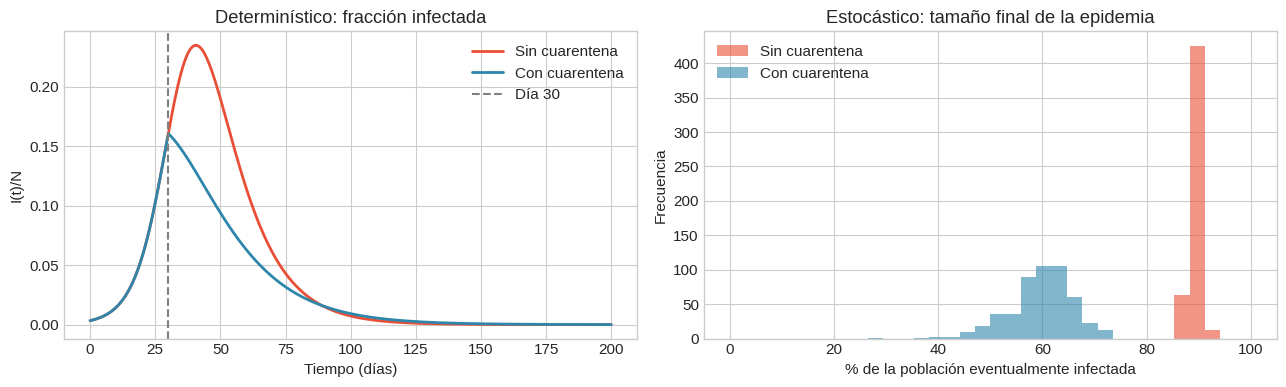

R0 = 1.20


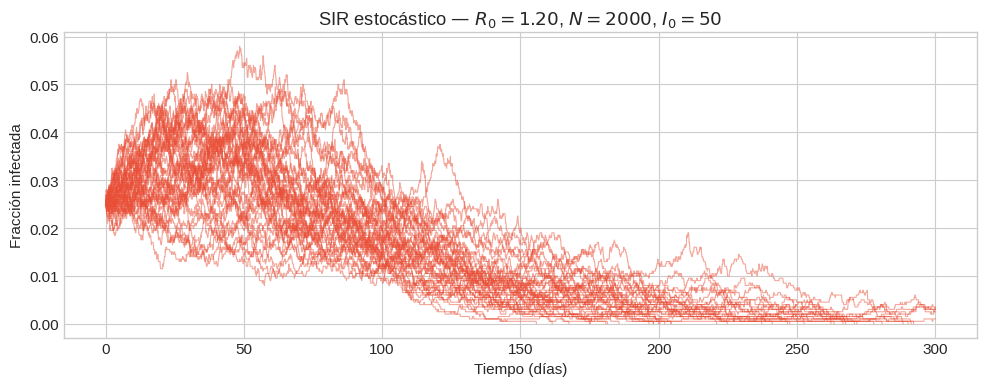

In [6]:
# Espacio para ejercicios

# =========================================================
# Ejercicio 1: Cuarentena (beta se reduce a la mitad desde el día 30)
# =========================================================

def sir_ode_quarantine(y, t, beta, gamma, t_quarantine=30, beta_factor=0.5):
    S, I, R = y
    N = S + I + R
    beta_t = beta if t < t_quarantine else beta * beta_factor
    dS = -beta_t * S * I / N
    dI =  beta_t * S * I / N - gamma * I
    dR =  gamma * I
    return [dS, dI, dR]

def run_sir_deterministic_quarantine(N, I0, beta, gamma, t_quarantine=30, beta_factor=0.5, t_max=200):
    y0 = [N - I0, I0, 0]
    t = np.linspace(0, t_max, t_max * 2)
    sol = odeint(sir_ode_quarantine, y0, t, args=(beta, gamma, t_quarantine, beta_factor))
    return t, sol[:, 0], sol[:, 1], sol[:, 2]

def sir_stochastic_quarantine(N, I0, beta, gamma, t_quarantine=30, beta_factor=0.5, t_max=300, dt=0.1):
    S, I, R = N - I0, I0, 0
    t = 0
    ts, Ss, Is, Rs = [t], [S], [I], [R]

    while t < t_max and I > 0:
        beta_t = beta if t < t_quarantine else beta * beta_factor

        n_infections = beta_t * S * I / N * dt
        n_recoveries = gamma * I * dt

        new_infections = rng.poisson(n_infections)
        new_recoveries = rng.poisson(n_recoveries)

        new_infections = min(new_infections, S)
        new_recoveries = min(new_recoveries, I)

        S -= new_infections
        I += new_infections - new_recoveries
        R += new_recoveries
        t += dt

        ts.append(t); Ss.append(S); Is.append(I); Rs.append(R)

    return np.array(ts), np.array(Ss), np.array(Is), np.array(Rs)

# =========================================================
# Ejercicio 2: Superspreaders
# 10% de infectados transmiten con 5*beta, el resto con 0.5*beta
# =========================================================

def sir_stochastic_superspreaders(N, I0, beta, gamma, p_super=0.10,
                                  mult_super=5.0, mult_regular=0.5,
                                  t_max=300, dt=0.1):
    S, I, R = N - I0, I0, 0
    t = 0
    ts, Ss, Is, Rs = [t], [S], [I], [R]

    while t < t_max and I > 0:
        # Partición aleatoria de infectados
        I_super = rng.binomial(I, p_super)
        I_regular = I - I_super

        # Presión infecciosa total
        n_infections = beta * (mult_super * I_super + mult_regular * I_regular) * S / N * dt
        n_recoveries = gamma * I * dt

        new_infections = rng.poisson(n_infections)
        new_recoveries = rng.poisson(n_recoveries)

        new_infections = min(new_infections, S)
        new_recoveries = min(new_recoveries, I)

        S -= new_infections
        I += new_infections - new_recoveries
        R += new_recoveries
        t += dt

        ts.append(t); Ss.append(S); Is.append(I); Rs.append(R)

    return np.array(ts), np.array(Ss), np.array(Is), np.array(Rs)

# Parámetros
N_sp = 1_000
I0_sp = 1
beta_sp = 0.20
gamma_sp = 0.10
n_sims_sp = 1000

final_base = []
final_super = []
peak_base = []
peak_super = []

for _ in range(n_sims_sp):
    _, _, I_b, R_b = sir_stochastic(N_sp, I0_sp, beta_sp, gamma_sp)
    final_base.append(R_b[-1] / N_sp)
    peak_base.append(I_b.max() / N_sp)

    _, _, I_s, R_s = sir_stochastic_superspreaders(N_sp, I0_sp, beta_sp, gamma_sp)
    final_super.append(R_s[-1] / N_sp)
    peak_super.append(I_s.max() / N_sp)

final_base = np.array(final_base)
final_super = np.array(final_super)
peak_base = np.array(peak_base)
peak_super = np.array(peak_super)

print(f"Sin superspreaders -> media tamaño final: {final_base.mean():.2%}, std: {final_base.std():.2%}")
print(f"Con superspreaders -> media tamaño final: {final_super.mean():.2%}, std: {final_super.std():.2%}")
print()
print(f"Sin superspreaders -> P(extinción <5%): {(final_base < 0.05).mean():.2%}")
print(f"Con superspreaders -> P(extinción <5%): {(final_super < 0.05).mean():.2%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

bins = np.linspace(0, 1, 35) * 100
ax1.hist(final_base * 100, bins=bins, alpha=0.6, label="Base", color=COLORS["blue"])
ax1.hist(final_super * 100, bins=bins, alpha=0.6, label="Superspreaders", color=COLORS["orange"])
ax1.set_title("Distribución del tamaño final")
ax1.set_xlabel("% de la población infectada")
ax1.set_ylabel("Frecuencia")
ax1.legend()

ax2.boxplot([peak_base * 100, peak_super * 100],
            labels=["Base", "Superspreaders"],
            patch_artist=True,
            boxprops=dict(facecolor="lightblue"),
            medianprops=dict(color="red", lw=2))
ax2.set_title("Pico de infección")
ax2.set_ylabel("% máximo infectado simultáneamente")

plt.tight_layout()
plt.show()

# =========================================================
# Ejercicio 3: Detección tardía
# I0 = 50, R0 = 1.2
# =========================================================

N_dt = 2_000
I0_dt = 50
gamma_dt = 0.1
beta_dt = 0.12   # R0 = 1.2
R0_dt = beta_dt / gamma_dt
n_sims_dt = 400

print(f"R0 = {R0_dt:.2f}")

# Determinístico
t_det, S_det, I_det, R_det = run_sir_deterministic(N_dt, I0_dt, beta_dt, gamma_dt, t_max=200)

# Simulaciones estocásticas
t_grid = np.linspace(0, 200, 401)
I_paths = []
final_sizes = []
n_epidemics = 0

for _ in range(n_sims_dt):
    ts, Ss, Is, Rs = sir_stochastic(N_dt, I0_dt, beta_dt, gamma_dt, t_max=200)
    I_interp = np.interp(t_grid, ts, Is, left=Is[0], right=Is[-1]) / N_dt
    I_paths.append(I_interp)

    final_frac = Rs[-1] / N_dt
    final_sizes.append(final_frac)

    if final_frac > 0.05:
        n_epidemics += 1

I_paths = np.array(I_paths)
mean_I = I_paths.mean(axis=0)
q10 = np.quantile(I_paths, 0.10, axis=0)
q90 = np.quantile(I_paths, 0.90, axis=0)

I_det_interp = np.interp(t_grid, t_det, I_det) / N_dt

# Criterio operativo de "divergencia visible":
# primer tiempo en que la media estocástica difiere del determinístico en más de 2 puntos porcentuales
diff = np.abs(mean_I - I_det_interp)
idx = np.where(diff > 0.02)[0]
div_time = t_grid[idx[0]] if len(idx) > 0 else np.nan

print(f"Simulaciones con epidemia (>5% de N): {n_epidemics}/{n_sims_dt} = {n_epidemics/n_sims_dt:.2%}")
print(f"Tamaño final promedio (estocástico): {np.mean(final_sizes):.2%}")
print(f"Tamaño final determinístico:        {R_det[-1]/N_dt:.2%}")

if np.isnan(div_time):
    print("Con este criterio (2 puntos porcentuales), no hubo divergencia visible clara entre la media estocástica y el determinístico.")
else:
    print(f"Divergencia visible aproximada: día {div_time:.1f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Algunas trayectorias
for i in range(25):
    ax1.plot(t_grid, I_paths[i], color=COLORS["red"], alpha=0.25, lw=0.8)
ax1.plot(t_det, I_det / N_dt, color="black", lw=2, label="Determinístico")
ax1.set_title("Trayectorias individuales vs determinístico")
ax1.set_xlabel("Tiempo (días)")
ax1.set_ylabel("Fracción infectada")
ax1.legend()

# Media + banda 10-90%
ax2.plot(t_det, I_det / N_dt, color="black", lw=2, label="Determinístico")
ax2.plot(t_grid, mean_I, color=COLORS["blue"], lw=2, label="Media estocástica")
ax2.fill_between(t_grid, q10, q90, color=COLORS["blue"], alpha=0.2, label="Banda 10%-90%")
ax2.set_title("Promedio estocástico y dispersión")
ax2.set_xlabel("Tiempo (días)")
ax2.set_ylabel("Fracción infectada")
ax2.legend()

plt.tight_layout()
plt.show()

# Parámetros del ejercicio
N_q = 3_000
I0_q = 10
beta_q = 0.25
gamma_q = 0.1
t_quarantine = 30
beta_factor = 0.5
n_sims_q = 500

# Determinístico: sin cuarentena vs con cuarentena
t_base, S_base, I_base, R_base = run_sir_deterministic(N_q, I0_q, beta_q, gamma_q)
t_quar, S_quar, I_quar, R_quar = run_sir_deterministic_quarantine(
    N_q, I0_q, beta_q, gamma_q, t_quarantine=t_quarantine, beta_factor=beta_factor
)

# Estocástico: comparar tamaños finales
final_base = []
final_quar = []
peak_base = []
peak_quar = []

for _ in range(n_sims_q):
    _, _, I_s, R_s = sir_stochastic(N_q, I0_q, beta_q, gamma_q)
    final_base.append(R_s[-1] / N_q)
    peak_base.append(I_s.max() / N_q)

    _, _, I_s_q, R_s_q = sir_stochastic_quarantine(
        N_q, I0_q, beta_q, gamma_q, t_quarantine=t_quarantine, beta_factor=beta_factor
    )
    final_quar.append(R_s_q[-1] / N_q)
    peak_quar.append(I_s_q.max() / N_q)

final_base = np.array(final_base)
final_quar = np.array(final_quar)
peak_base = np.array(peak_base)
peak_quar = np.array(peak_quar)

print(f"Tamaño final promedio sin cuarentena: {final_base.mean():.2%}")
print(f"Tamaño final promedio con cuarentena: {final_quar.mean():.2%}")
print(f"Reducción relativa del tamaño final: {(1 - final_quar.mean()/final_base.mean()):.2%}")
print()
print(f"Pico promedio sin cuarentena: {peak_base.mean():.2%}")
print(f"Pico promedio con cuarentena: {peak_quar.mean():.2%}")
print(f"Reducción relativa del pico: {(1 - peak_quar.mean()/peak_base.mean()):.2%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Trayectorias determinísticas
ax1.plot(t_base, I_base / N_q, lw=2, color=COLORS["red"], label="Sin cuarentena")
ax1.plot(t_quar, I_quar / N_q, lw=2, color=COLORS["blue"], label="Con cuarentena")
ax1.axvline(t_quarantine, color="gray", ls="--", lw=1.5, label="Día 30")
ax1.set_title("Determinístico: fracción infectada")
ax1.set_xlabel("Tiempo (días)")
ax1.set_ylabel("I(t)/N")
ax1.legend()

# Distribución del tamaño final
bins = np.linspace(0, 1, 35)
ax2.hist(final_base * 100, bins=bins * 100, alpha=0.6, label="Sin cuarentena", color=COLORS["red"])
ax2.hist(final_quar * 100, bins=bins * 100, alpha=0.6, label="Con cuarentena", color=COLORS["blue"])
ax2.set_title("Estocástico: tamaño final de la epidemia")
ax2.set_xlabel("% de la población eventualmente infectada")
ax2.set_ylabel("Frecuencia")
ax2.legend()

plt.tight_layout()
plt.show()

# Parámetros
N_ex = 2_000
beta_ex  = 0.12
gamma_ex = 0.1
I0_ex = 50
R0_ex = beta_ex / gamma_ex
print(f"R0 = {R0_ex:.2f}")

# Ejecuta algunas simulaciones y explora
n_runs_ex = 40
fig, ax = plt.subplots(figsize=(10, 4))
for _ in range(n_runs_ex):
    ts, Ss, Is, Rs = sir_stochastic(N_ex, I0_ex, beta_ex, gamma_ex)
    ax.plot(ts, Is/N_ex, lw=0.8, alpha=0.5, color=COLORS["red"])
ax.set_xlabel("Tiempo (días)")
ax.set_ylabel("Fracción infectada")
ax.set_title(f"SIR estocástico — $R_0 = {R0_ex:.2f}$, $N = {N_ex}$, $I_0 = {I0_ex}$")
plt.tight_layout()
plt.show()

### Conclusión: cuarentena

Modelé una intervención que reduce $\beta$ a la mitad a partir del día 30. En ambas versiones, determinística y estocástica, la cuarentena reduce el pico de infectados y también el tamaño final de la epidemia.

En mi corrida, la reducción del tamaño final promedio fue de alrededor de 33% y la reducción del pico promedio fue de alrededor de 37%. La idea teórica es directa: al bajar $\beta$, baja $R_0=\beta/\gamma$, por lo que disminuye la presión de contagio.

### Conclusión: superspreaders

Modifiqué el modelo para que en cada paso de tiempo 10% de los infectados actúe como superspreader con tasa $5\beta$, mientras que el resto transmite con tasa $0.5\beta$.

La comparación correcta aquí no es solo la media, sino la **distribución** de resultados: tamaño final, pico de infección y probabilidad de extinción temprana. En este tipo de ejercicio, la heterogeneidad en transmisión puede volver más irregular la dinámica y hacer más dispersos los resultados que en el modelo homogéneo.

### Conclusión: detección tardía

Tomé el escenario pedido por el enunciado:
$
I_0 = 50, \qquad R_0 = 1.2.
$

Como $R_0$ está apenas por arriba de 1, el modelo determinístico todavía predice crecimiento, pero la interpretación correcta del modelo estocástico es probabilística: no solo importa la trayectoria media, sino también la dispersión entre corridas.

En mi implementación conté como “epidemia” cualquier corrida con tamaño final mayor a 5% de la población. Además, para objetivar “divergencia visible”, definí como primer tiempo de divergencia el momento en que la media estocástica se separa del determinístico por más de 2 puntos porcentuales.

## Conclusión final de la aplicación SIR

El modelo SIR determinístico da una trayectoria única para cada conjunto de parámetros, mientras que el modelo estocástico produce una **distribución de trayectorias**.

En los ejercicios finales se ve que:

- una intervención sobre $\beta$ puede reducir fuertemente el pico y el tamaño final;
- la heterogeneidad en transmisión cambia la distribución de resultados, no solo su media;
- cerca del umbral $R_0 = 1$, la interpretación correcta debe ser probabilística y no puramente determinística.